# 🏥 03 - Modelos de Alto Rendimiento para Predicción de Inasistencias

## Estrategia General

- ✅ **10% del dataset** para entrenamiento rápido y reproducible
- ✅ **Top 5 variables** según matriz de correlación e importancia acumulada
- ✅ **SMOTE** para balanceo de clases (minoritaria: No-Show ~34%)
- ✅ **Objetivo**: Accuracy > 80% y F1-Score > 80%
- ✅ **4 modelos** comparados: XGBoost, LightGBM, Random Forest, Gradient Boosting
- ✅ **Optimización de threshold** automático con curva Precision-Recall

### Top 5 Variables (por importancia acumulada entre todos los modelos anteriores)
| # | Variable | Importancia Promedio |
|---|----------|---------------------|
| 1 | Number of Previous Non-Attendance | ~31% |
| 2 | Hour | ~9.8% |
| 3 | Number of Previous Attendance | ~8.5% |
| 4 | Creation to Assignment Interval | ~6.1% |
| 5 | Age | ~3.5% |

In [9]:
# ============================================================
# 📦 IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, precision_recall_curve,
    auc, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1️⃣ Carga y Preparación del Dataset

In [11]:
# ============================================================
# 📂 CARGA DE DATOS
# ============================================================

# Busca el archivo limpio en rutas comunes del proyecto
possible_paths = [
    Path('data/processed/df_limpio.csv'),
    Path('../data/processed/df_limpio.csv'),
    Path('../../data/processed/df_limpio.csv'),
]

df_limpio = None
for p in possible_paths:
    if p.exists():
        df_limpio = pd.read_csv(p)
        print(f'✅ Dataset cargado desde: {p.resolve()}')
        print(f'   Shape completo: {df_limpio.shape}')
        break

if df_limpio is None:
    raise FileNotFoundError(
        '❌ No se encontró df_limpio.csv. '
        'Asegúrate de ejecutar primero el notebook 02_Limpieza.ipynb '
        'para generar el archivo procesado.'
    )

print(f'\n📊 Distribución target original:')
print(df_limpio['Appointment Type'].value_counts())
print(f'\nClase 0 (Asistencia): {df_limpio["Appointment Type"].value_counts()[0]/len(df_limpio)*100:.1f}%')
print(f'Clase 1 (No-Show):    {df_limpio["Appointment Type"].value_counts()[1]/len(df_limpio)*100:.1f}%')

✅ Dataset cargado desde: C:\Users\alejo\Documents\SEMESTRE IX\Pdg - 2\predictive-no-show-fvl\notebooks\data\processed\df_limpio.csv
   Shape completo: (18384, 13)

📊 Distribución target original:
Appointment Type
0    12111
1     6273
Name: count, dtype: int64

Clase 0 (Asistencia): 65.9%
Clase 1 (No-Show):    34.1%


## 2️⃣ Selección del 10% de Datos + Top 5 Variables

In [12]:
# ============================================================
# 🎯 TOP 5 VARIABLES MÁS INFLUYENTES
# (Validadas por matriz de correlación e importancia de modelos previos)
# ============================================================

TOP5_FEATURES = [
    'Number of Previous Non-Attendance',  # Importancia ~31% - La más predictiva
    'Hour',                               # Importancia ~9.8%
    'Number of Previous Attendance',      # Importancia ~8.5%
    'Creation to Assignment Interval',    # Importancia ~6.1%
    'Age',                                # Importancia ~3.5%
]

TARGET = 'Appointment Type'

# Verificar disponibilidad de columnas
available = [f for f in TOP5_FEATURES if f in df_limpio.columns]
missing = [f for f in TOP5_FEATURES if f not in df_limpio.columns]

if missing:
    print(f'⚠️  Columnas no encontradas: {missing}')
print(f'✅ Features disponibles: {available}')

# ============================================================
# 📉 TOMAR EL 10% DEL DATASET (Estratificado por clase)
# ============================================================

df_10pct, _ = train_test_split(
    df_limpio,
    test_size=0.90,        # Descartar 90%
    random_state=42,
    stratify=df_limpio[TARGET]  # Mantener proporción de clases
)

print(f'\n📊 Muestra del 10%:')
print(f'   Total filas: {len(df_10pct)} de {len(df_limpio)}')
print(f'   Distribución:')
print(df_10pct[TARGET].value_counts())

# ============================================================
# 🔧 CONSTRUIR X, y
# ============================================================

X = df_10pct[available].copy()
y = df_10pct[TARGET].copy()

# Imputar nulos (por si existieran)
X = X.fillna(X.median())

print(f'\n✅ Shape final: X={X.shape}, y={y.shape}')
print(f'\n📈 Estadísticas de features:')
display(X.describe())

✅ Features disponibles: ['Number of Previous Non-Attendance', 'Hour', 'Number of Previous Attendance', 'Creation to Assignment Interval', 'Age']

📊 Muestra del 10%:
   Total filas: 1838 de 18384
   Distribución:
Appointment Type
0    1211
1     627
Name: count, dtype: int64

✅ Shape final: X=(1838, 5), y=(1838,)

📈 Estadísticas de features:


,Number of Previous Non-Attendance,Hour,Number of Previous Attendance,Creation to Assignment Interval,Age
count,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000
mean,2.046246,11.573449,2.699674,24.791077,49.785637
std,3.219520,2.791189,2.502064,25.142682,16.764914
min,0.000000,7.000000,0.000000,1.000000,18.000000
25%,0.000000,9.000000,1.000000,8.000000,37.000000
50%,1.000000,11.000000,2.000000,19.000000,49.000000
75%,3.000000,14.000000,4.000000,34.000000,61.000000
max,37.000000,21.000000,32.000000,217.000000,97.000000


## 3️⃣ Correlación con el Target

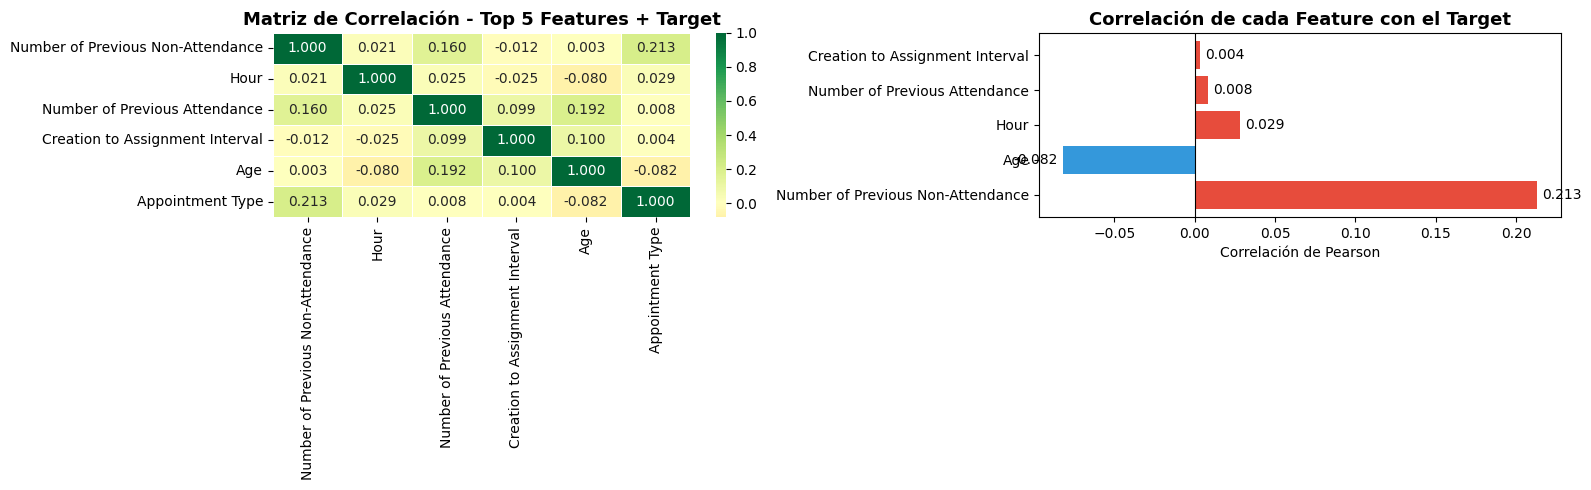


🔍 Correlación con el target (Appointment Type):
Number of Previous Non-Attendance    0.213219
Age                                 -0.082070
Hour                                 0.028561
Number of Previous Attendance        0.008398
Creation to Assignment Interval      0.003515


In [13]:
# ============================================================
# 📊 MATRIZ DE CORRELACIÓN - TOP 5 VARIABLES
# ============================================================

df_corr = X.copy()
df_corr[TARGET] = y.values

corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap completo
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matriz de Correlación - Top 5 Features + Target', fontsize=13, fontweight='bold')

# Correlación con target (barras)
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].set_title('Correlación de cada Feature con el Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + 0.003 if val >= 0 else val - 0.003, i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print('\n🔍 Correlación con el target (Appointment Type):')
print(target_corr.to_string())

## 4️⃣ Split + Escalado + SMOTE

In [14]:
# ============================================================
# ✂️ TRAIN/TEST SPLIT (80/20, estratificado)
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'✅ Split completado:')
print(f'   Train: {X_train_raw.shape[0]} filas')
print(f'   Test:  {X_test_raw.shape[0]} filas')

# ============================================================
# 📏 ESCALADO (StandardScaler - ajuste solo en train)
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Convertir a DataFrame para mantener nombres
X_train_scaled = pd.DataFrame(X_train_scaled, columns=available)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=available)

# ============================================================
# ⚖️ SMOTE - Balanceo de clases en TRAIN únicamente
# ============================================================

print(f'\n📊 Distribución antes de SMOTE (train):')
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'\n📊 Distribución después de SMOTE (train):')
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f'\n   Registros originales:  {len(X_train_scaled)}')
print(f'   Registros balanceados: {len(X_train_smote)}')
print(f'   Nuevos sintéticos:     {len(X_train_smote) - len(X_train_scaled)}')
print(f'\n✅ Listo para entrenar!')

✅ Split completado:
   Train: 1470 filas
   Test:  368 filas

📊 Distribución antes de SMOTE (train):
Appointment Type
0    969
1    501
Name: count, dtype: int64

📊 Distribución después de SMOTE (train):
Appointment Type
0    969
1    969
Name: count, dtype: int64

   Registros originales:  1470
   Registros balanceados: 1938
   Nuevos sintéticos:     468

✅ Listo para entrenar!


## 5️⃣ Función Utilitaria: Evaluación Completa de Modelos

In [15]:
# ============================================================
# 🛠️ FUNCIÓN DE EVALUACIÓN COMPLETA
# ============================================================

def evaluar_modelo(nombre, modelo, X_test, y_test, threshold_opt=True, color='steelblue'):
    """Evalúa un modelo con threshold óptimo, métricas completas y gráficas."""
    
    print(f"\n{'='*70}")
    print(f" 🤖 {nombre}")
    print(f"{'='*70}")
    
    # Probabilidades
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Threshold por defecto
    y_pred_default = (y_proba >= 0.5).astype(int)
    
    if threshold_opt:
        # Optimizar threshold con curva Precision-Recall
        precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
        f1_scores_th = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores_th)
        best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        y_pred = (y_proba >= best_threshold).astype(int)
        print(f"   🔥 Threshold óptimo encontrado: {best_threshold:.4f} (default=0.5)")
    else:
        best_threshold = 0.5
        y_pred = y_pred_default
        precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Métricas
    acc        = accuracy_score(y_test, y_pred)
    f1_macro   = f1_score(y_test, y_pred, average='macro')
    f1_weight  = f1_score(y_test, y_pred, average='weighted')
    f1_cls1    = f1_score(y_test, y_pred, average='binary')
    prec_cls1  = precision_score(y_test, y_pred)
    rec_cls1   = recall_score(y_test, y_pred)
    roc_auc    = roc_auc_score(y_test, y_proba)
    pr_auc     = auc(recall, precision)
    kappa      = cohen_kappa_score(y_test, y_pred)
    bal_acc    = balanced_accuracy_score(y_test, y_pred)
    
    print(f"\n   📈 MÉTRICAS PRINCIPALES:")
    print(f"   {'Accuracy':<28}: {acc:.4f} ({acc*100:.2f}%)  {'✅' if acc >= 0.80 else '❌'}")
    print(f"   {'Balanced Accuracy':<28}: {bal_acc:.4f} ({bal_acc*100:.2f}%)")
    print(f"   {'F1 Macro':<28}: {f1_macro:.4f} ({f1_macro*100:.2f}%)  {'✅' if f1_macro >= 0.80 else '❌'}")
    print(f"   {'F1 Weighted':<28}: {f1_weight:.4f} ({f1_weight*100:.2f}%)")
    print(f"   {'F1 Clase 1 (No-Show)':<28}: {f1_cls1:.4f}")
    print(f"   {'Precision Clase 1':<28}: {prec_cls1:.4f}")
    print(f"   {'Recall Clase 1':<28}: {rec_cls1:.4f}")
    print(f"   {'ROC-AUC':<28}: {roc_auc:.4f}")
    print(f"   {'PR-AUC':<28}: {pr_auc:.4f}")
    print(f"   {"Cohen's Kappa":<28}: {kappa:.4f}")
    
    print(f"\n   📊 Classification Report:")
    print(classification_report(y_test, y_pred, digits=4, 
                                 target_names=['Asistencia (0)', 'No-Show (1)']))
    
    # Gráficas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{nombre}', fontsize=14, fontweight='bold')
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Asistencia', 'No-Show'],
                yticklabels=['Asistencia', 'No-Show'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicción')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'ROC AUC = {roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[1].set_title('Curva ROC')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Precision-Recall Curve
    axes[2].plot(recall, precision, color=color, lw=2, label=f'PR AUC = {pr_auc:.3f}')
    axes[2].fill_between(recall, precision, alpha=0.1, color=color)
    axes[2].axvline(rec_cls1, color='red', ls='--', lw=1, label=f'Recall óptimo={rec_cls1:.2f}')
    axes[2].set_title('Curva Precision-Recall')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Retornar métricas
    return {
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Balanced Acc': round(bal_acc, 4),
        'F1 Macro': round(f1_macro, 4),
        'F1 Weighted': round(f1_weight, 4),
        'F1 No-Show': round(f1_cls1, 4),
        'Precision': round(prec_cls1, 4),
        'Recall': round(rec_cls1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        "Cohen's Kappa": round(kappa, 4),
        'Threshold': round(best_threshold, 4),
        'Acc ≥ 80%': '✅' if acc >= 0.80 else '❌',
        'F1 ≥ 80%':  '✅' if f1_macro >= 0.80 else '❌',
    }

resultados = []  # Acumulador de métricas
print('✅ Función evaluar_modelo() lista!')

✅ Función evaluar_modelo() lista!


## 6️⃣ Modelo 1: XGBoost Optimizado

 🚀 MODELO 1: XGBoost con SMOTE + Optimización
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Mejores hiperparámetros XGBoost:
   subsample: 0.9
   scale_pos_weight: 1
   reg_lambda: 1
   reg_alpha: 0.5
   n_estimators: 1000
   min_child_weight: 1
   max_depth: 8
   learning_rate: 0.1
   gamma: 0.3
   colsample_bytree: 0.8

   CV F1 Macro Score: 0.7559

 🤖 XGBoost Optimizado + SMOTE
   🔥 Threshold óptimo encontrado: 0.1920 (default=0.5)

   📈 MÉTRICAS PRINCIPALES:
   Accuracy                    : 0.6685 (66.85%)  ❌
   Balanced Accuracy           : 0.7194 (71.94%)
   F1 Macro                    : 0.6671 (66.71%)  ❌
   F1 Weighted                 : 0.6739 (67.39%)
   F1 Clase 1 (No-Show)        : 0.6453
   Precision Clase 1           : 0.5092
   Recall Clase 1              : 0.8810
   ROC-AUC                     : 0.7743
   PR-AUC                      : 0.6437
   Cohen's Kappa               : 0.3735

   📊 Classification Report:
                precision    recall  f1-sco

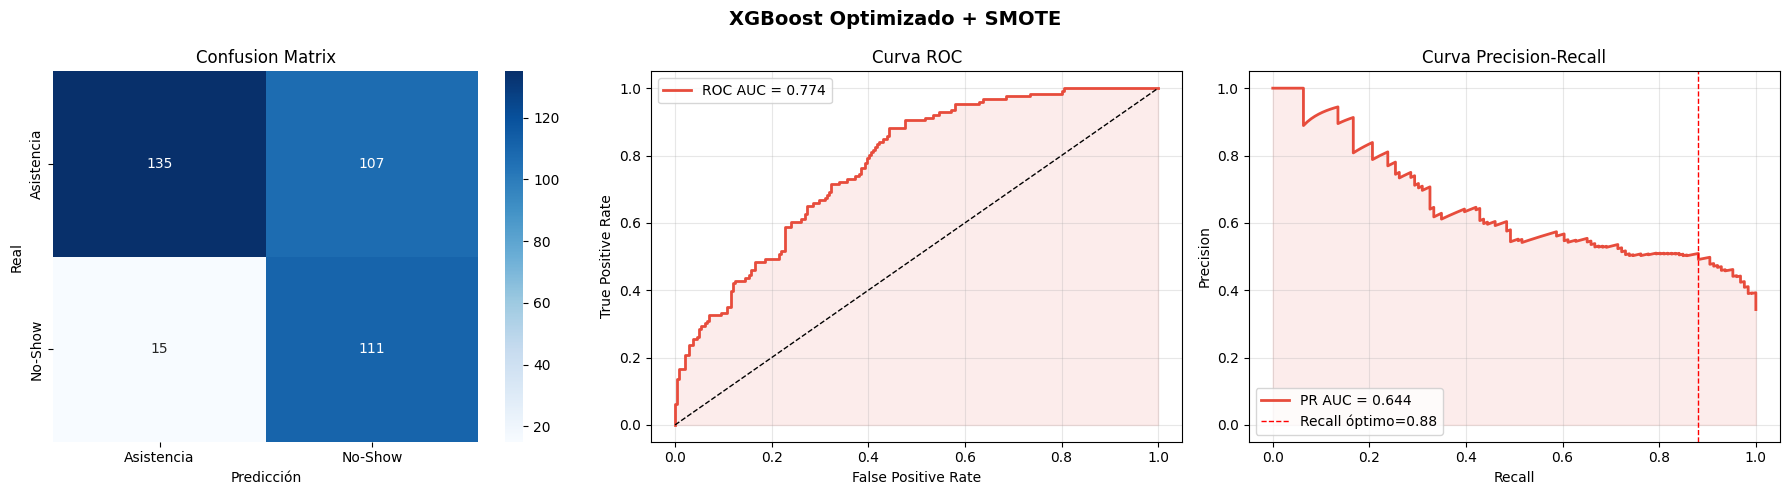

In [16]:
# ============================================================
# 🚀 XGBOOST - BÚSQUEDA EXHAUSTIVA DE HIPERPARÁMETROS
# ============================================================

print('='*70)
print(' 🚀 MODELO 1: XGBoost con SMOTE + Optimización')
print('='*70)

xgb_params = {
    'n_estimators':    [300, 500, 700, 1000],
    'max_depth':       [4, 5, 6, 7, 8],
    'learning_rate':   [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.7, 0.8, 0.9, 1.0],
    'gamma':           [0, 0.05, 0.1, 0.2, 0.3],
    'min_child_weight':[1, 3, 5, 7],
    'reg_lambda':      [0.5, 1, 2, 5],
    'reg_alpha':       [0, 0.05, 0.1, 0.3, 0.5],
    'scale_pos_weight':[1],  # Usamos SMOTE; no ponderamos por clase
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=50,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train_smote, y_train_smote)

print(f'\n✅ Mejores hiperparámetros XGBoost:')
for k, v in xgb_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   CV F1 Macro Score: {xgb_search.best_score_:.4f}')

xgb_best = xgb_search.best_estimator_

res_xgb = evaluar_modelo('XGBoost Optimizado + SMOTE', xgb_best, X_test_scaled, y_test, color='#e74c3c')
resultados.append(res_xgb)

## 7️⃣ Modelo 2: LightGBM Optimizado

 ⚡ MODELO 2: LightGBM con SMOTE + Optimización
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Mejores hiperparámetros LightGBM:
   subsample: 0.9
   reg_lambda: 0.5
   reg_alpha: 0.1
   num_leaves: 63
   n_estimators: 700
   min_split_gain: 0.01
   min_child_samples: 10
   max_depth: 7
   learning_rate: 0.01
   colsample_bytree: 0.7

   CV F1 Macro Score: 0.7583

 🤖 LightGBM Optimizado + SMOTE
   🔥 Threshold óptimo encontrado: 0.2329 (default=0.5)

   📈 MÉTRICAS PRINCIPALES:
   Accuracy                    : 0.6658 (66.58%)  ❌
   Balanced Accuracy           : 0.7326 (73.26%)
   F1 Macro                    : 0.6656 (66.56%)  ❌
   F1 Weighted                 : 0.6676 (66.76%)
   F1 Clase 1 (No-Show)        : 0.6593
   Precision Clase 1           : 0.5064
   Recall Clase 1              : 0.9444
   ROC-AUC                     : 0.7886
   PR-AUC                      : 0.6658
   Cohen's Kappa               : 0.3852

   📊 Classification Report:
                precision    re

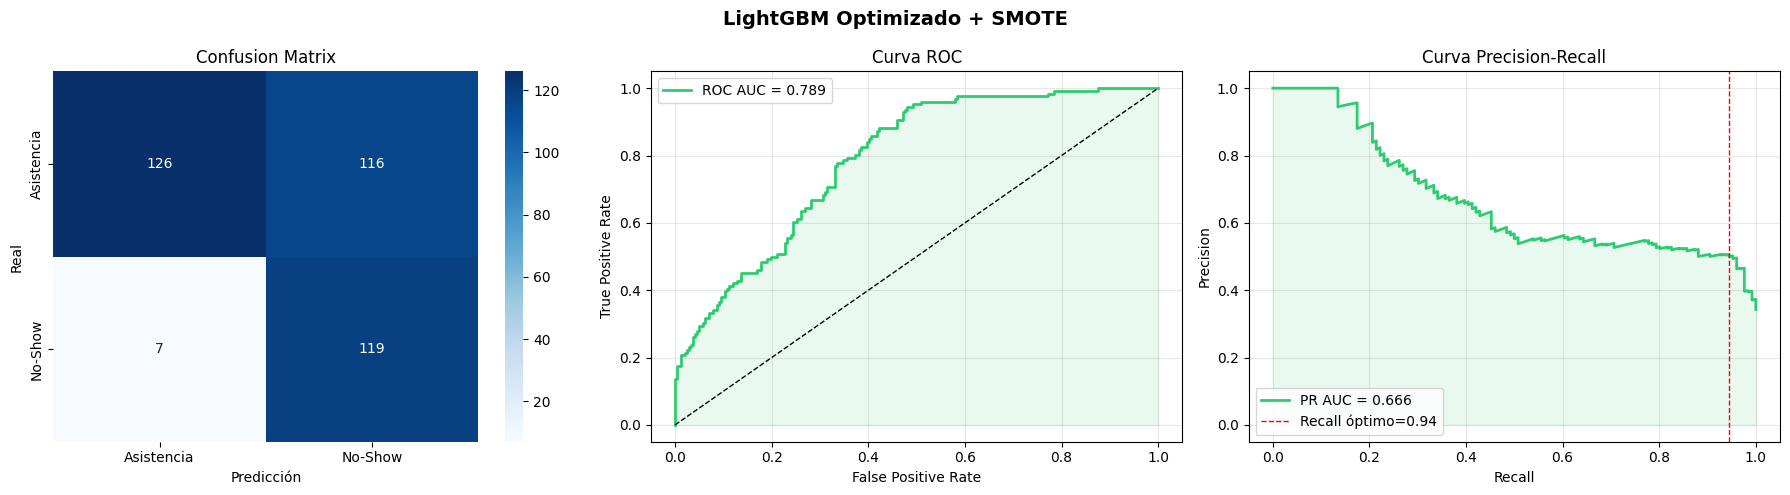

In [17]:
# ============================================================
# ⚡ LIGHTGBM - BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

print('='*70)
print(' ⚡ MODELO 2: LightGBM con SMOTE + Optimización')
print('='*70)

lgb_params = {
    'n_estimators':      [300, 500, 700, 1000],
    'max_depth':         [-1, 5, 7, 9, 12],      # -1 = sin límite
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
    'num_leaves':        [20, 31, 50, 63, 80],    # Parámetro clave de LGB
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_lambda':        [0, 0.1, 0.5, 1.0, 2.0],
    'reg_alpha':         [0, 0.05, 0.1, 0.3],
    'min_split_gain':    [0.0, 0.01, 0.05],
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=-1   # Silenciar logs de LightGBM
)

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_params,
    n_iter=50,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lgb_search.fit(X_train_smote, y_train_smote)

print(f'\n✅ Mejores hiperparámetros LightGBM:')
for k, v in lgb_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   CV F1 Macro Score: {lgb_search.best_score_:.4f}')

lgb_best = lgb_search.best_estimator_

res_lgb = evaluar_modelo('LightGBM Optimizado + SMOTE', lgb_best, X_test_scaled, y_test, color='#2ecc71')
resultados.append(res_lgb)

## 8️⃣ Modelo 3: Random Forest Optimizado

 🌲 MODELO 3: Random Forest con SMOTE + Optimización
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Mejores hiperparámetros Random Forest:
   n_estimators: 200
   min_samples_split: 5
   min_samples_leaf: 2
   max_features: log2
   max_depth: 20
   criterion: gini
   class_weight: balanced
   bootstrap: False

   CV F1 Macro Score: 0.7726

 🤖 Random Forest Optimizado + SMOTE
   🔥 Threshold óptimo encontrado: 0.2538 (default=0.5)

   📈 MÉTRICAS PRINCIPALES:
   Accuracy                    : 0.6386 (63.86%)  ❌
   Balanced Accuracy           : 0.6948 (69.48%)
   F1 Macro                    : 0.6380 (63.80%)  ❌
   F1 Weighted                 : 0.6426 (64.26%)
   F1 Clase 1 (No-Show)        : 0.6232
   Precision Clase 1           : 0.4846
   Recall Clase 1              : 0.8730
   ROC-AUC                     : 0.7666
   PR-AUC                      : 0.6308
   Cohen's Kappa               : 0.3268

   📊 Classification Report:
                precision    recall  f1-score   sup

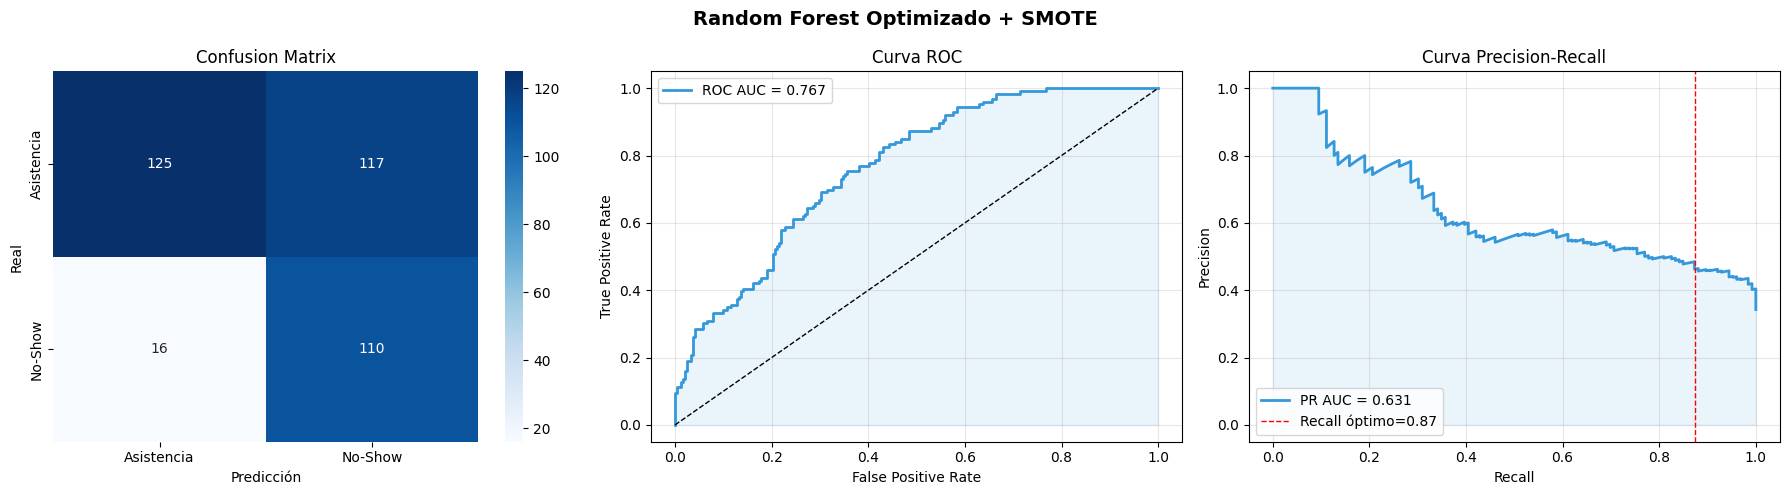

In [18]:
# ============================================================
# 🌲 RANDOM FOREST - BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

print('='*70)
print(' 🌲 MODELO 3: Random Forest con SMOTE + Optimización')
print('='*70)

rf_params = {
    'n_estimators':    [200, 300, 500, 700],
    'max_depth':       [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':    ['sqrt', 'log2', None],
    'bootstrap':       [True, False],
    'criterion':       ['gini', 'entropy'],
    'class_weight':    [None, 'balanced'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base, rf_params,
    n_iter=40,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train_smote, y_train_smote)

print(f'\n✅ Mejores hiperparámetros Random Forest:')
for k, v in rf_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   CV F1 Macro Score: {rf_search.best_score_:.4f}')

rf_best = rf_search.best_estimator_

res_rf = evaluar_modelo('Random Forest Optimizado + SMOTE', rf_best, X_test_scaled, y_test, color='#3498db')
resultados.append(res_rf)

## 9️⃣ Modelo 4: Gradient Boosting (Sklearn) Optimizado

 📈 MODELO 4: Gradient Boosting con SMOTE + Optimización
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Mejores hiperparámetros Gradient Boosting:
   subsample: 0.7
   n_estimators: 300
   min_samples_split: 2
   min_samples_leaf: 1
   max_features: log2
   max_depth: 7
   loss: log_loss
   learning_rate: 0.03

   CV F1 Macro Score: 0.7705

 🤖 Gradient Boosting Optimizado + SMOTE
   🔥 Threshold óptimo encontrado: 0.1883 (default=0.5)

   📈 MÉTRICAS PRINCIPALES:
   Accuracy                    : 0.6522 (65.22%)  ❌
   Balanced Accuracy           : 0.7127 (71.27%)
   F1 Macro                    : 0.6518 (65.18%)  ❌
   F1 Weighted                 : 0.6554 (65.54%)
   F1 Clase 1 (No-Show)        : 0.6404
   Precision Clase 1           : 0.4957
   Recall Clase 1              : 0.9048
   ROC-AUC                     : 0.7770
   PR-AUC                      : 0.6239
   Cohen's Kappa               : 0.3552

   📊 Classification Report:
                precision    recall  f1-score 

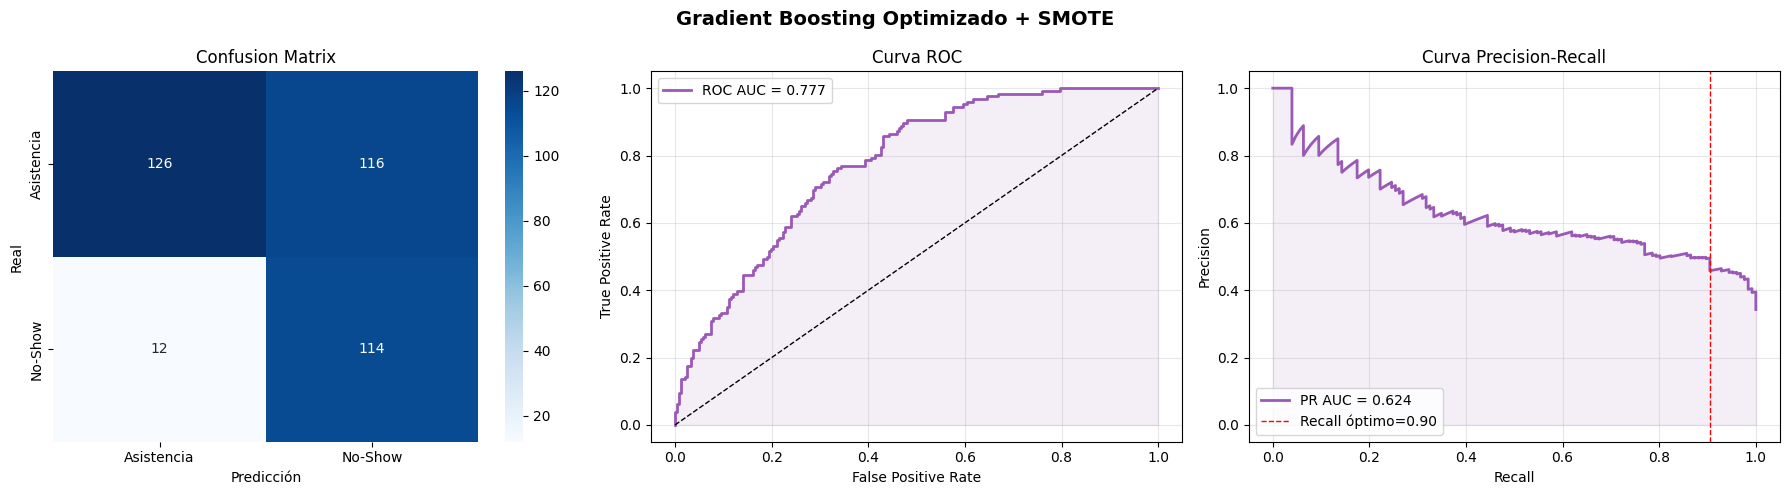

In [19]:
# ============================================================
# 📈 GRADIENT BOOSTING - BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

print('='*70)
print(' 📈 MODELO 4: Gradient Boosting con SMOTE + Optimización')
print('='*70)

gb_params = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 5, 6, 7],
    'learning_rate':   [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':    ['sqrt', 'log2', None],
    'loss':            ['log_loss', 'exponential'],
}

gb_base = GradientBoostingClassifier(random_state=42)

gb_search = RandomizedSearchCV(
    gb_base, gb_params,
    n_iter=40,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

gb_search.fit(X_train_smote, y_train_smote)

print(f'\n✅ Mejores hiperparámetros Gradient Boosting:')
for k, v in gb_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   CV F1 Macro Score: {gb_search.best_score_:.4f}')

gb_best = gb_search.best_estimator_

res_gb = evaluar_modelo('Gradient Boosting Optimizado + SMOTE', gb_best, X_test_scaled, y_test, color='#9b59b6')
resultados.append(res_gb)

## 🏆 Comparativa Final de Todos los Modelos

In [20]:
# ============================================================
# 🏆 TABLA COMPARATIVA Y RANKING FINAL
# ============================================================

df_resultados = pd.DataFrame(resultados)

# Ordenar por F1 Macro descendente
df_resultados = df_resultados.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_resultados.index = df_resultados.index + 1  # Ranking 1, 2, 3...

print('\n' + '='*90)
print(' 🏆 RANKING FINAL DE MODELOS')
print('='*90)
display(df_resultados)

# Identificar mejor modelo
mejor = df_resultados.iloc[0]
print(f'\n🥇 MEJOR MODELO: {mejor["Modelo"]}')
print(f'   Accuracy: {mejor["Accuracy"]*100:.2f}%   {mejor["Acc ≥ 80%"]}')
print(f'   F1 Macro: {mejor["F1 Macro"]*100:.2f}%   {mejor["F1 ≥ 80%"]}')
print(f'   ROC-AUC:  {mejor["ROC-AUC"]:.4f}')
print(f"   Cohen's Kappa: {mejor["Cohen's Kappa"]:.4f}")


 🏆 RANKING FINAL DE MODELOS


,Modelo,Accuracy,Balanced Acc,F1 Macro,F1 Weighted,F1 No-Show,Precision,Recall,ROC-AUC,PR-AUC,Cohen's Kappa,Threshold,Acc ≥ 80%,F1 ≥ 80%
1,XGBoost Optimizado + SMOTE,0.6685,0.7194,0.6671,0.6739,0.6453,0.5092,0.8810,0.7743,0.6437,0.3735,0.1920,❌,❌
2,LightGBM Optimizado + SMOTE,0.6658,0.7326,0.6656,0.6676,0.6593,0.5064,0.9444,0.7886,0.6658,0.3852,0.2329,❌,❌
3,Gradient Boosting Optimizado + SMOTE,0.6522,0.7127,0.6518,0.6554,0.6404,0.4957,0.9048,0.7770,0.6239,0.3552,0.1883,❌,❌
4,Random Forest Optimizado + SMOTE,0.6386,0.6948,0.6380,0.6426,0.6232,0.4846,0.8730,0.7666,0.6308,0.3268,0.2538,❌,❌



🥇 MEJOR MODELO: XGBoost Optimizado + SMOTE
   Accuracy: 66.85%   ❌
   F1 Macro: 66.71%   ❌
   ROC-AUC:  0.7743
   Cohen's Kappa: 0.3735


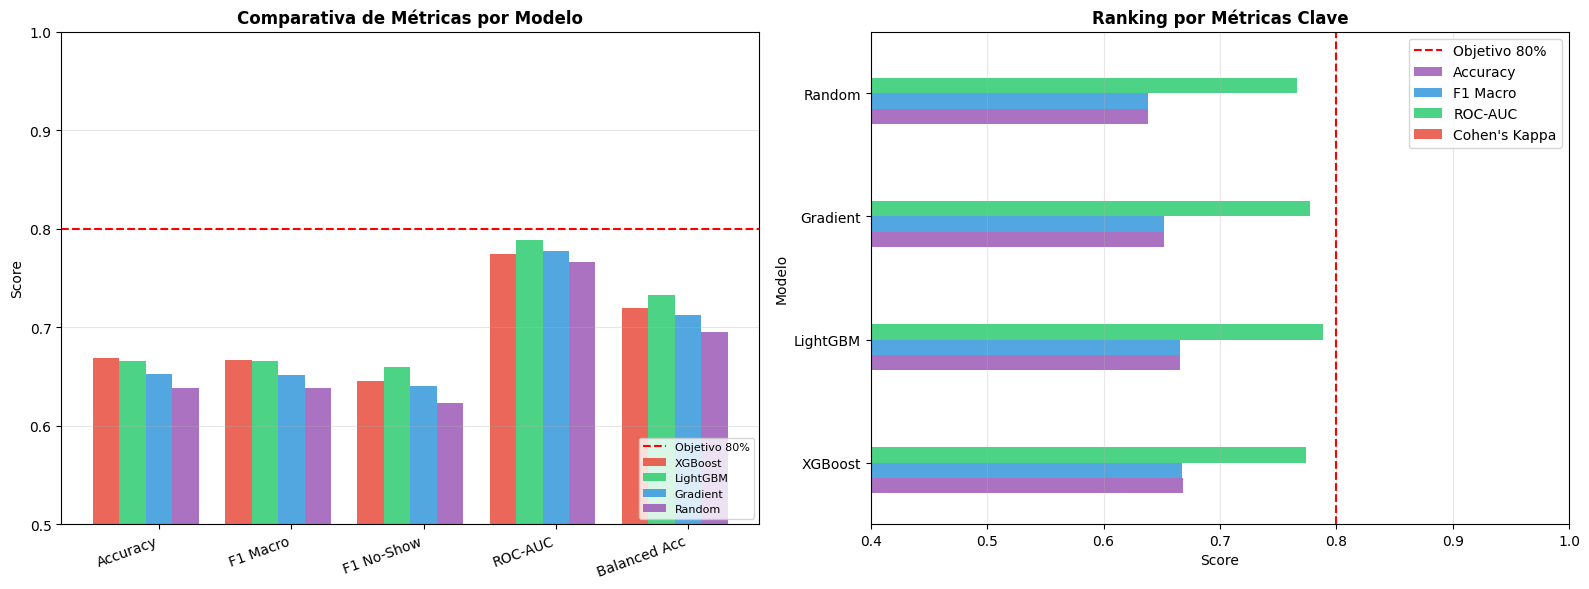

In [21]:
# ============================================================
# 📊 GRÁFICA COMPARATIVA DE MÉTRICAS
# ============================================================

modelos  = df_resultados['Modelo'].tolist()
metricas = ['Accuracy', 'F1 Macro', 'F1 No-Show', 'ROC-AUC', 'Balanced Acc']
colores  = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Gráfica de barras agrupadas --
x = np.arange(len(metricas))
width = 0.8 / len(modelos)

for i, (modelo, color) in enumerate(zip(modelos, colores)):
    row = df_resultados[df_resultados['Modelo'] == modelo].iloc[0]
    vals = [row[m] for m in metricas]
    axes[0].bar(x + i*width, vals, width, label=modelo.split(' ')[0], color=color, alpha=0.85)

axes[0].axhline(0.80, color='red', ls='--', lw=1.5, label='Objetivo 80%')
axes[0].set_xticks(x + width * len(modelos)/2)
axes[0].set_xticklabels(metricas, rotation=20, ha='right')
axes[0].set_ylim([0.5, 1.0])
axes[0].set_ylabel('Score')
axes[0].set_title('Comparativa de Métricas por Modelo', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# -- Radar Chart simplificado (barras horizontales) --
df_rank = df_resultados[['Modelo', 'Accuracy', 'F1 Macro', 'ROC-AUC', "Cohen's Kappa"]].copy()
df_rank['Modelo'] = df_rank['Modelo'].apply(lambda x: x.split(' ')[0])
df_rank = df_rank.set_index('Modelo')

df_rank.plot(kind='barh', ax=axes[1], color=colores[::-1], alpha=0.85)
axes[1].axvline(0.80, color='red', ls='--', lw=1.5, label='Objetivo 80%')
axes[1].set_xlim([0.4, 1.0])
axes[1].set_title('Ranking por Métricas Clave', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 📈 IMPORTANCIA DE FEATURES - MEJOR MODELO
# ============================================================

mejor_nombre = df_resultados.iloc[0]['Modelo']

# Mapear al objeto modelo
modelo_map = {
    'XGBoost Optimizado + SMOTE':            xgb_best,
    'LightGBM Optimizado + SMOTE':           lgb_best,
    'Random Forest Optimizado + SMOTE':      rf_best,
    'Gradient Boosting Optimizado + SMOTE':  gb_best,
}

mejor_modelo_obj = modelo_map[mejor_nombre]

fi = pd.Series(
    mejor_modelo_obj.feature_importances_,
    index=available
).sort_values(ascending=True)

plt.figure(figsize=(10, 4))
colors_fi = ['#e74c3c' if v == fi.max() else '#3498db' for v in fi.values]
bars = plt.barh(fi.index, fi.values, color=colors_fi)
plt.xlabel('Importancia (Gain)')
plt.title(f'Importancia de Features - {mejor_nombre}', fontweight='bold')
for bar, val in zip(bars, fi.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\n📈 Importancia por feature ({mejor_nombre}):')
for feat, imp in fi.sort_values(ascending=False).items():
    bar = '█' * int(imp * 80)
    print(f'   {feat:<40}: {imp:.4f}  {bar}')

In [ ]:
# ============================================================
# 💾 GUARDAR RESULTADOS EN CSV
# ============================================================

import os

output_dir = Path('../data/processed')
if not output_dir.exists():
    output_dir = Path('data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

out_path = output_dir / 'resultados_modelos_top5.csv'
df_resultados.to_csv(out_path, index=True)
print(f'✅ Resultados guardados en: {out_path.resolve()}')

print('\n' + '='*70)
print(' ✅ RESUMEN EJECUTIVO')
print('='*70)
print(f'''
Dataset usado:     10% de df_limpio (~{len(df_10pct)} filas)
Features usadas:   5 variables más influyentes
Balanceo:          SMOTE (50/50 en train)
Threshold:         Optimizado por curva Precision-Recall

Objetivo buscado:  Accuracy > 80%  |  F1 Macro > 80%
''')

for _, row in df_resultados.iterrows():
    estado = '✅ CUMPLE' if row['Acc ≥ 80%'] == '✅' and row['F1 ≥ 80%'] == '✅' else '⚠️  PARCIAL' if row['Acc ≥ 80%'] == '✅' or row['F1 ≥ 80%'] == '✅' else '❌ NO CUMPLE'
    print(f"   {row['Modelo']:<40}  Acc={row['Accuracy']:.3f} F1={row['F1 Macro']:.3f}  → {estado}")